In [4]:
!pip install yellowbrick

  Using cached yellowbrick-1.5-py3-none-any.whl.metadata (7.7 kB)
Using cached yellowbrick-1.5-py3-none-any.whl (282 kB)


In [5]:
import pandas as pd
import numpy as np
import yellowbrick
from yellowbrick.text.correlation import WordCorrelationPlot

import nltk
nltk.download('popular')
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('stopwords')

from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to

In [21]:
def lemmatize_text(text):
    '''
    Lemmatizes the provided string and returns it.
    @param text : a string of unlemmatized text
    @return a lemmatized string
    '''
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word.lower()) for word in text.split()]
    return ' '.join(lemmatized_words)


def remove_stop_words(text):
    '''
    Removes stop words from the provided string and returns it.
    @param text : a string that contains stop words
    @return a string without stop words
    '''
    stop_words = set(stopwords.words('english'))
    filtered_sentence = [word for word in text.split() if word not in stop_words]
    return ' '.join(filtered_sentence)


def get_clean_odyssey_data():
    '''
    Pipeline to load Odyssey data into a dataframe, lemmatize it, remove stop words, and return as a dataframe.
    @return a dataframe containing preprocessed text
    '''
    odyssey_df = pd.read_csv('odyssey.csv')
    odyssey_df['content'] = odyssey_df['content'].apply(lemmatize_text)
    odyssey_df['content'] = odyssey_df['content'].apply(remove_stop_words)
    return odyssey_df

def preprocessing(corpus):
    ''' Turns corpus into list of words and returns book content as a list of words
        @param corpus : a dataframe with preprocecced text
        @return : list of words
    '''
    training_data = []
    for ind,row in corpus.iterrows():
      training_data.append(row['content'].split(" "))
    return training_data


odyssey_df = get_clean_odyssey_data() # cleaned text data frame
list_of_books = preprocessing(odyssey_df)

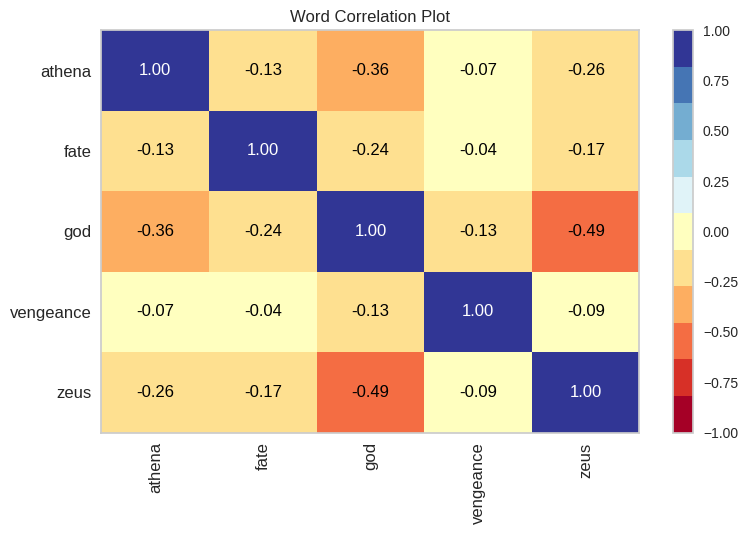

<Axes: title={'center': 'Word Correlation Plot'}>

In [27]:
# Fix 1: Define megalist correctly
megalist = []

for book in list_of_books:
    for word in book:
        if word in ["zeus" , "athena", "god", "hero", "right", "requital", "vengeance", "prophecy", "fate"]:
            megalist.append(word)

# Fix 4: List of target words
words = ["fate", "zeus", "vengeance", "god", "athena"]

viz = WordCorrelationPlot(words, min_occurrence=1)
viz.fit(megalist)
viz.show()